In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav_history = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv"
)

nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

In [5]:
fund_code = 120843
fund_data = (nav_history[
        nav_history["amfi_code"] == fund_code
    ]
    .sort_values("date")
    .copy()
)

fund_data["daily_return"] = (
    fund_data["nav"]
    .pct_change()
)

returns = (
    fund_data["daily_return"]
    .dropna()
)

In [6]:
mu = returns.mean()

sigma = returns.std()

current_nav = (
    fund_data["nav"]
    .iloc[-1]
)

print(current_nav)

163.2397


In [7]:
simulation_days = 252 * 5

num_simulations = 1000

In [8]:
simulations = np.zeros(
    (
        simulation_days,
        num_simulations
    )
)

for i in range(num_simulations):

    prices = [current_nav]

    for j in range(simulation_days):

        random_return = np.random.normal(
            mu,
            sigma
        )

        prices.append(
            prices[-1]
            * (1 + random_return)
        )

    simulations[:, i] = prices[1:]

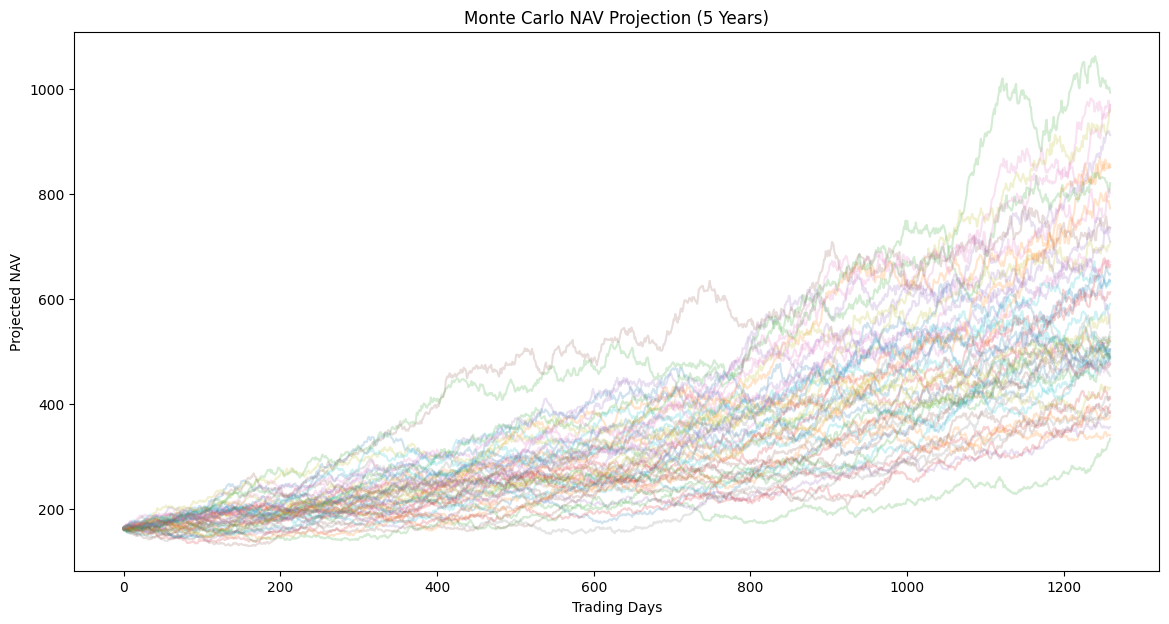

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(14,7))

plt.plot(
    simulations[:, :50],
    alpha=0.2
)

plt.title(
    "Monte Carlo NAV Projection (5 Years)"
)

plt.xlabel(
    "Trading Days"
)

plt.ylabel(
    "Projected NAV"
)

plt.show()


In [17]:
final_values = simulations[-1]
expected_nav = np.mean(
    final_values
)
best_case = np.percentile(
    final_values,
    95
)

worst_case = np.percentile(
    final_values,
    5
)

print(
    f"Current NAV: {current_nav:.2f}"
)

print(
    f"Expected NAV (5Y): {expected_nav:.2f}"
)

print(
    f"Best Case (95th percentile): {best_case:.2f}"
)

print(
    f"Worst Case (5th percentile): {worst_case:.2f}"
)


Current NAV: 163.24
Expected NAV (5Y): 635.38
Best Case (95th percentile): 1054.25
Worst Case (5th percentile): 338.36


### Monte Carlo NAV Forecast

A Monte Carlo simulation was performed using historical daily return distributions to project possible NAV trajectories over the next five years. The analysis generated 1,000 potential scenarios and estimated expected, optimistic, and pessimistic outcomes. This provides a probabilistic view of future fund performance rather than relying on a single deterministic forecast.